# 06 - Analisis Korelasi Fitur

## Objective
- Menghitung matriks korelasi antar fitur.
- Mengidentifikasi pasangan fitur Vesta (V-features) dengan korelasi sangat tinggi ($|r| > 0.95$) dan membuang yang redundan.
- Menganalisis fitur apa saja yang memiliki korelasi linear terkuat dengan target (`isFraud`).
- Menyimpan daftar fitur redundan untuk digunakan pada tahap modeling.

### Impor Library & Load Data

In [1]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

TRAIN_PATH = Path('../data/interim/train_merged.parquet')
METADATA_DIR = Path('../data/metadata')

train = pd.read_parquet(TRAIN_PATH)
print(f'Data loaded: {train.shape}')

Data loaded: (590540, 434)


### Filter Kolom Numerik & Pengambilan Sampel

In [2]:
EXCLUDE_COLS = ['TransactionID', 'TransactionDT', 'isFraud']

numeric_cols = [
    c for c in train.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE_COLS
]
print(f'Numeric features: {len(numeric_cols)}')

# Ambil sampel 50.000 baris untuk efisiensi komputasi korelasi
SAMPLE_N = 50_000
sample = train[numeric_cols + ['isFraud']].sample(n=SAMPLE_N, random_state=42)

Numeric features: 400


### Analisis: Distribusi Korelasi Fitur vs isFraud

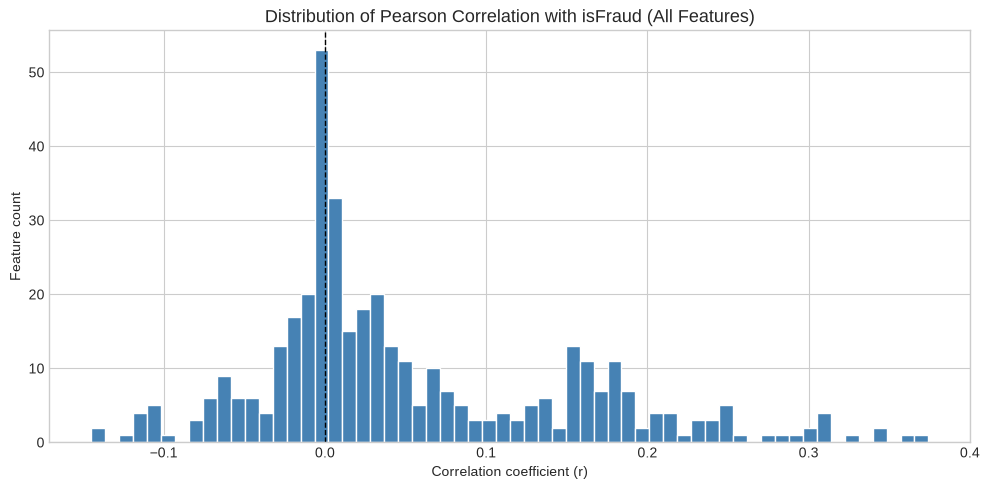

Most positive: V305 (nan)
Most negative: D8 (-0.1449)


In [3]:
# Hitung korelasi Pearson semua fitur numerik terhadap isFraud
target_corr_all = (
    sample.corr()['isFraud']
    .drop('isFraud')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(target_corr_all, bins=60, color='steelblue', edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_title('Distribution of Pearson Correlation with isFraud (All Features)', fontsize=13)
ax.set_xlabel('Correlation coefficient (r)')
ax.set_ylabel('Feature count')
plt.tight_layout()
plt.show()

print(f'Most positive: {target_corr_all.index[-1]} ({target_corr_all.iloc[-1]:.4f})')
print(f'Most negative: {target_corr_all.index[0]} ({target_corr_all.iloc[0]:.4f})')

### Analisis: Top 15 Fitur Berkorelasi Terkuat

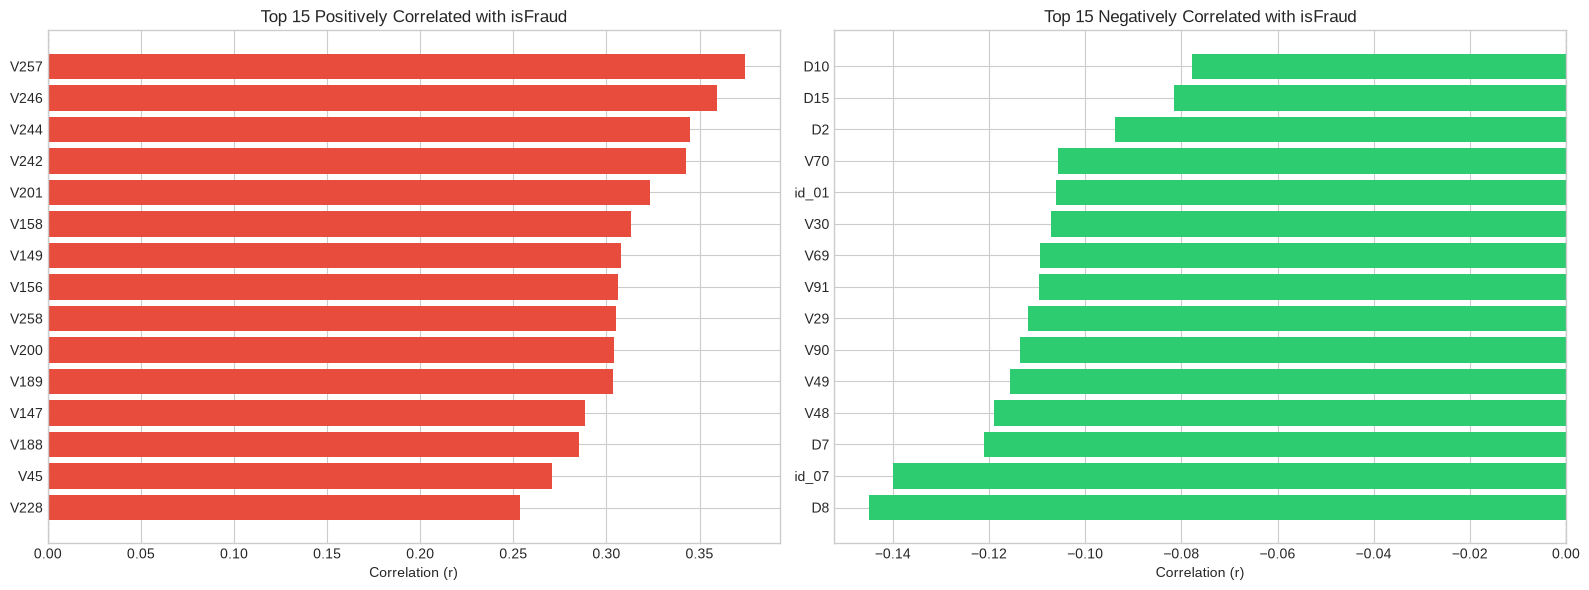

Top 10 Positive Correlation with isFraud:
V257    0.374249
V246    0.359296
V244    0.345097
V242    0.342966
V201    0.323567
V158    0.313141
V149    0.307625
V156    0.306064
V258    0.305055
V200    0.303986

Top 10 Negative Correlation with isFraud:
D8      -0.144923
id_07   -0.139978
D7      -0.120997
V48     -0.118922
V49     -0.115667
V90     -0.113630
V29     -0.111872
V91     -0.109524
V69     -0.109495
V30     -0.107133


In [4]:
# Ambil 15 korelasi positif tertinggi dan 15 korelasi negatif terendah
TOP_N = 15
top_positive = target_corr_all.nlargest(TOP_N)
top_negative = target_corr_all.nsmallest(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot korelasi positif
axes[0].barh(top_positive.index[::-1], top_positive.values[::-1], color='#e74c3c')
axes[0].set_title(f'Top {TOP_N} Positively Correlated with isFraud', fontsize=12)
axes[0].set_xlabel('Correlation (r)')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Plot korelasi negatif
axes[1].barh(top_negative.index, top_negative.values, color='#2ecc71')
axes[1].set_title(f'Top {TOP_N} Negatively Correlated with isFraud', fontsize=12)
axes[1].set_xlabel('Correlation (r)')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print('Top 10 Positive Correlation with isFraud:')
print(top_positive.head(10).to_string())
print('\nTop 10 Negative Correlation with isFraud:')
print(top_negative.head(10).to_string())

### Analisis: Heatmap Korelasi V-Features

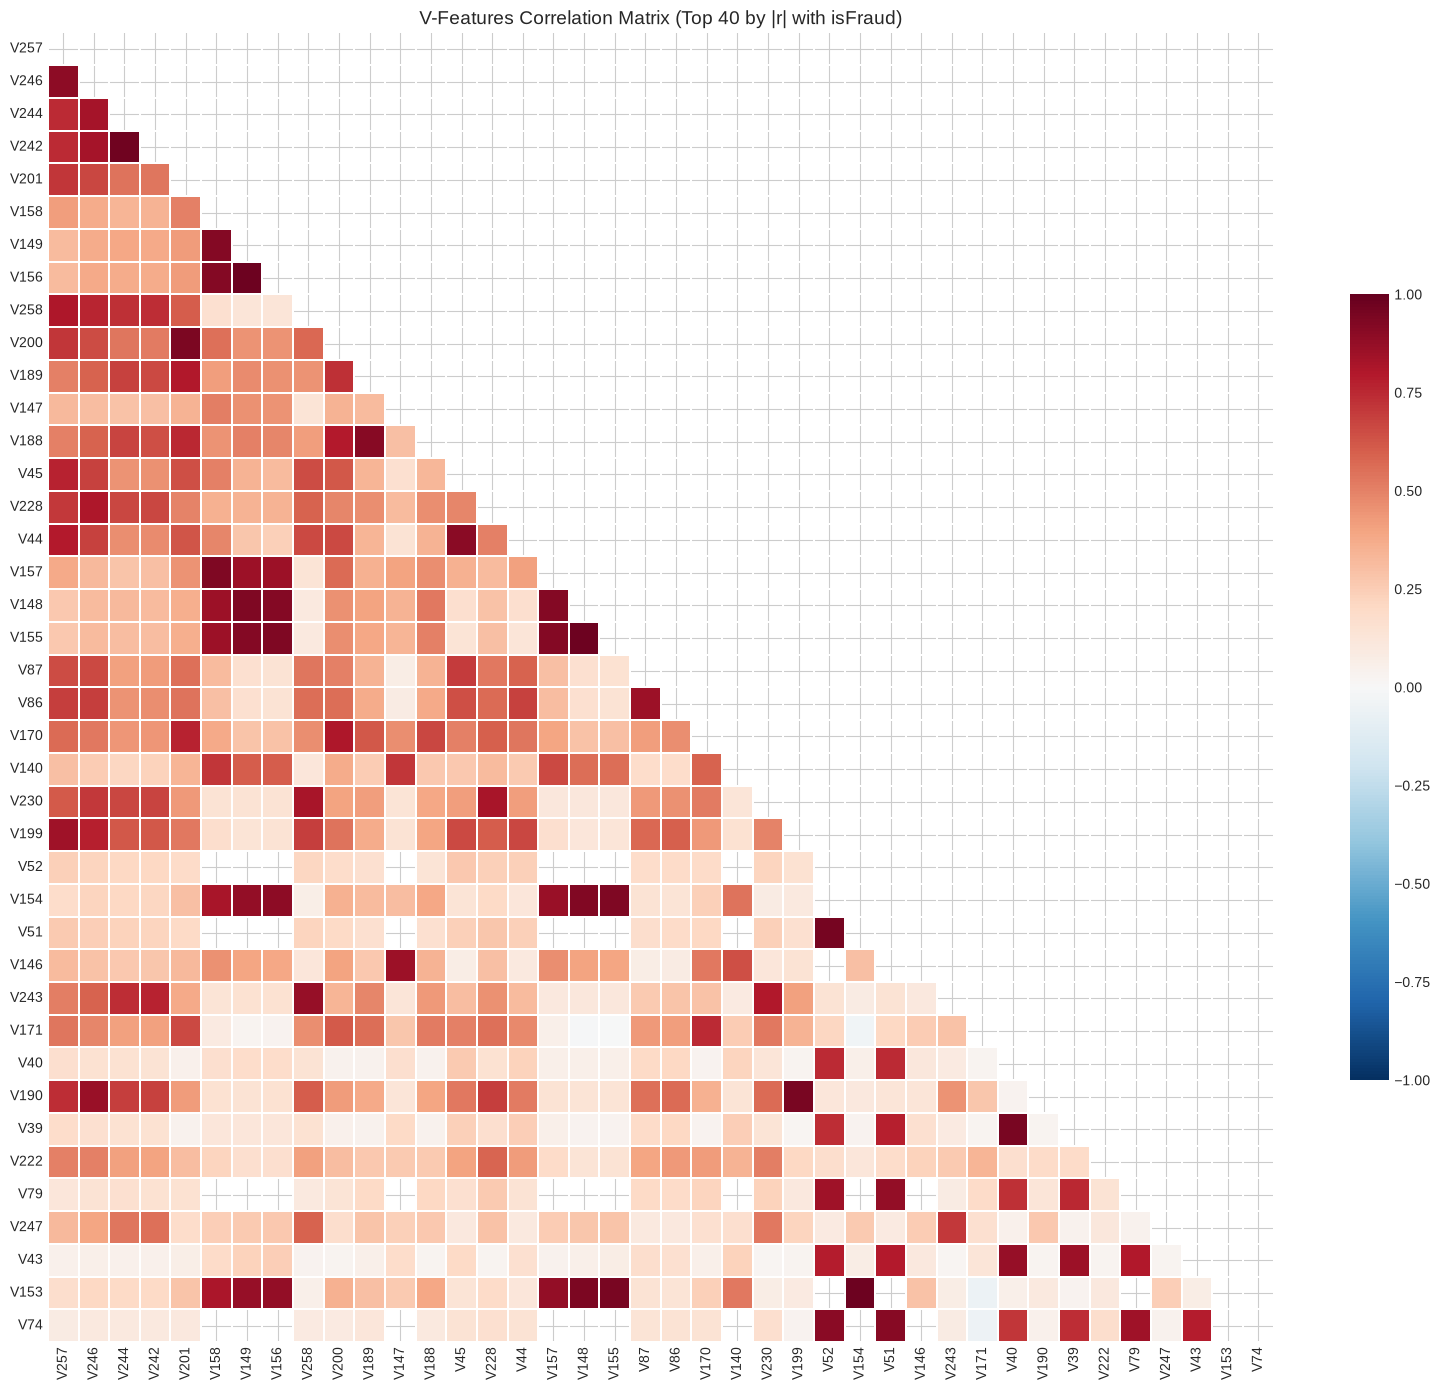

In [5]:
# Heatmap korelasi antar V-features (top 40 berdasarkan nilai absolut korelasi)
v_cols = [c for c in numeric_cols if c.startswith('V')]
v_target_corr = target_corr_all[v_cols].abs().sort_values(ascending=False)
top40_v = v_target_corr.head(40).index.tolist()

v_corr_matrix = sample[top40_v].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(v_corr_matrix, dtype=bool))
sns.heatmap(
    v_corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"shrink": 0.6}
)
ax.set_title('V-Features Correlation Matrix (Top 40 by |r| with isFraud)', fontsize=14)
plt.tight_layout()
plt.show()

### Eksplorasi: Cari V-Features dengan Korelasi Sangat Tinggi

In [6]:
# Cari semua pasangan V-features dengan korelasi |r| > 0.95
CORR_THRESHOLD = 0.95
v_corr_full = sample[v_cols].corr()

high_corr_pairs = []
for i in range(len(v_cols)):
    for j in range(i + 1, len(v_cols)):
        r = v_corr_full.iloc[i, j]
        if abs(r) > CORR_THRESHOLD:
            high_corr_pairs.append((v_cols[i], v_cols[j], r))

print(f'V-features: {len(v_cols)}')
print(f'Highly correlated pairs |r| > {CORR_THRESHOLD}: {len(high_corr_pairs)}')
print('\nSample pairs:')
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f'   {f1} - {f2}: {r:.4f}')

V-features: 339
Highly correlated pairs |r| > 0.95: 634

Sample pairs:
   V96 - V323: 1.0000
   V97 - V324: 1.0000
   V95 - V322: 0.9999
   V279 - V322: 0.9999
   V280 - V324: 0.9999
   V293 - V322: 0.9998
   V101 - V322: 0.9997
   V95 - V101: 0.9997
   V279 - V293: 0.9996
   V167 - V177: 0.9995


### Eliminasi (Pruning) Fitur Vesta yang Redundan

In [7]:
# Dari tiap pasangan korelasi tinggi, hapus fitur yang memiliki korelasi target lebih rendah
v_target_abs = target_corr_all[v_cols].abs()

to_remove = set()
for f1, f2, r in high_corr_pairs:
    # Pertahankan fitur yang korelasinya terhadap isFraud lebih kuat
    if v_target_abs.get(f1, 0) < v_target_abs.get(f2, 0):
        to_remove.add(f1)
    else:
        to_remove.add(f2)

print(f'Features recommended for removal : {len(to_remove)}')
print(f'Original V-features              : {len(v_cols)}')
print(f'After pruning                    : {len(v_cols) - len(to_remove)}')
print(f'Reduction                        : {len(to_remove) / len(v_cols) * 100:.1f}%')

Features recommended for removal : 130
Original V-features              : 339
After pruning                    : 209
Reduction                        : 38.3%


### Eksplorasi: Analisis Korelasi C-Features dan D-Features

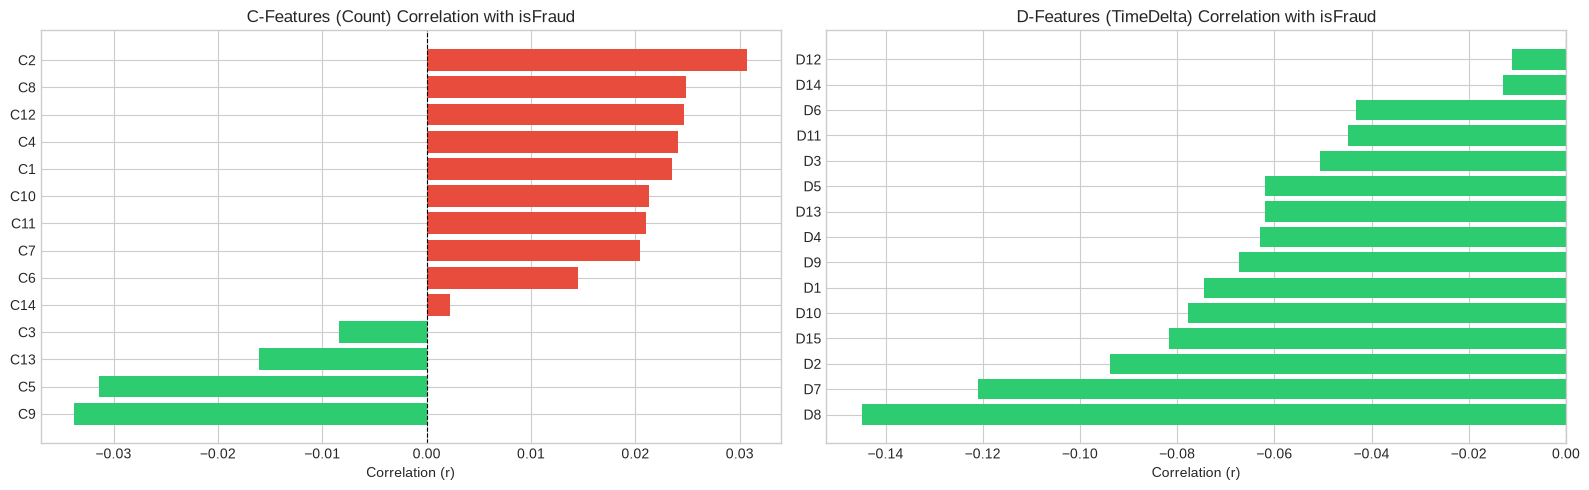

C-features: 14 | Mean |r|: 0.0212
D-features: 15 | Mean |r|: 0.0674


In [8]:
# Cek korelasi C-features (count) dan D-features (timedelta) terhadap isFraud
c_cols = [c for c in numeric_cols if c.startswith('C') and c[1:].isdigit()]
d_cols = [c for c in numeric_cols if c.startswith('D') and c[1:].isdigit()]

c_corr = target_corr_all[c_cols].sort_values()
d_corr = target_corr_all[d_cols].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(c_corr.index, c_corr.values, color=['#e74c3c' if v > 0 else '#2ecc71' for v in c_corr.values])
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('C-Features (Count) Correlation with isFraud', fontsize=12)
axes[0].set_xlabel('Correlation (r)')

axes[1].barh(d_corr.index, d_corr.values, color=['#e74c3c' if v > 0 else '#2ecc71' for v in d_corr.values])
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('D-Features (TimeDelta) Correlation with isFraud', fontsize=12)
axes[1].set_xlabel('Correlation (r)')

plt.tight_layout()
plt.show()

print(f'C-features: {len(c_cols)} | Mean |r|: {c_corr.abs().mean():.4f}')
print(f'D-features: {len(d_cols)} | Mean |r|: {d_corr.abs().mean():.4f}')

### save data

In [9]:
# Simpan daftar fitur redundan ke metadata agar bisa di-drop di notebook selanjutnya
METADATA_DIR.mkdir(parents=True, exist_ok=True)
output_path = METADATA_DIR / 'redundant_feature.csv'

pd.Series(list(to_remove), name='feature').to_csv(output_path, index=False)
print(f'Saved redundant feature list: {output_path}')
print(f'Features to drop: {len(to_remove)}')

Saved redundant feature list: ../data/metadata/redundant_feature.csv
Features to drop: 130
